11. Categorias 

In [2]:
import pandas as pd
df_base = pd.read_csv("../data/processed/base_analitica_final.csv")

/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99355/4194120273.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_categorias['product_category_name_english'], rotation=45, ha='right')


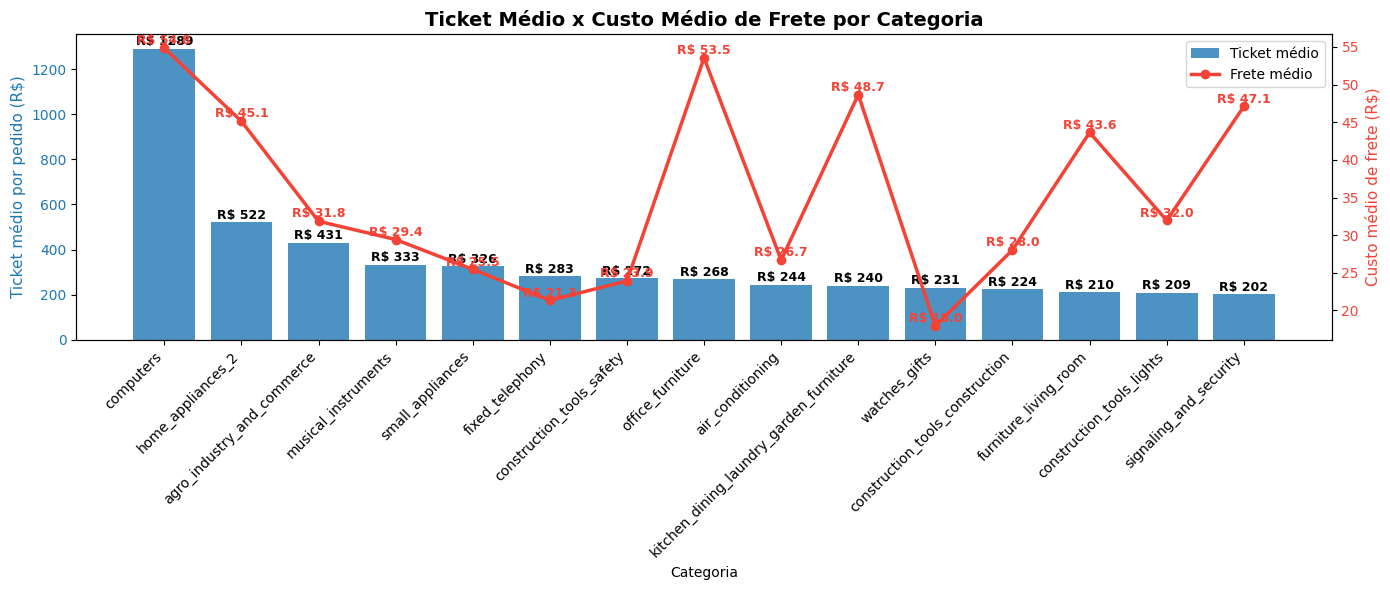

In [3]:
# ============================================================
# GRÁFICO — TICKET MÉDIO x CUSTO MÉDIO DE FRETE POR CATEGORIA
# ============================================================
# Objetivo:
# Comparar quanto cada categoria gera em valor médio por pedido
# e quanto custa, em média, o frete dessas compras.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa por categoria
categoria_financeiro = (
    df_base
    .groupby('product_category_name_english')
    .agg(
        ticket_medio=('ticket_total', 'mean'),
        frete_medio=('total_freight', 'mean'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Filtra categorias com volume mínimo para evitar distorção
categoria_financeiro = categoria_financeiro[categoria_financeiro['total_pedidos'] >= 100].copy()

# Ordena pelas categorias com maior ticket médio
categoria_financeiro = categoria_financeiro.sort_values('ticket_medio', ascending=False)

# Seleciona top categorias para o gráfico ficar legível
top_categorias = categoria_financeiro.head(15).copy()

# Cria gráfico
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras = ticket médio
bars = ax1.bar(
    top_categorias['product_category_name_english'],
    top_categorias['ticket_medio'],
    color='#1f77b4',
    alpha=0.8,
    label='Ticket médio'
)

ax1.set_ylabel('Ticket médio por pedido (R$)', color='#1f77b4', fontsize=11)
ax1.set_xlabel('Categoria')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_title('Ticket Médio x Custo Médio de Frete por Categoria', fontsize=14, fontweight='bold')
ax1.set_xticklabels(top_categorias['product_category_name_english'], rotation=45, ha='right')

# Linha = frete médio
ax2 = ax1.twinx()
ax2.plot(
    top_categorias['product_category_name_english'],
    top_categorias['frete_medio'],
    color='#F44336',
    marker='o',
    linewidth=2.5,
    label='Frete médio'
)

ax2.set_ylabel('Custo médio de frete (R$)', color='#F44336', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#F44336')

# Rótulos nas barras
for bar, val in zip(bars, top_categorias['ticket_medio']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'R$ {val:.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Rótulos na linha
for x, y in zip(top_categorias['product_category_name_english'], top_categorias['frete_medio']):
    ax2.text(
        x, y + 0.5,
        f'R$ {y:.1f}',
        color='#F44336',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Legenda combinada
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99355/403360403.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


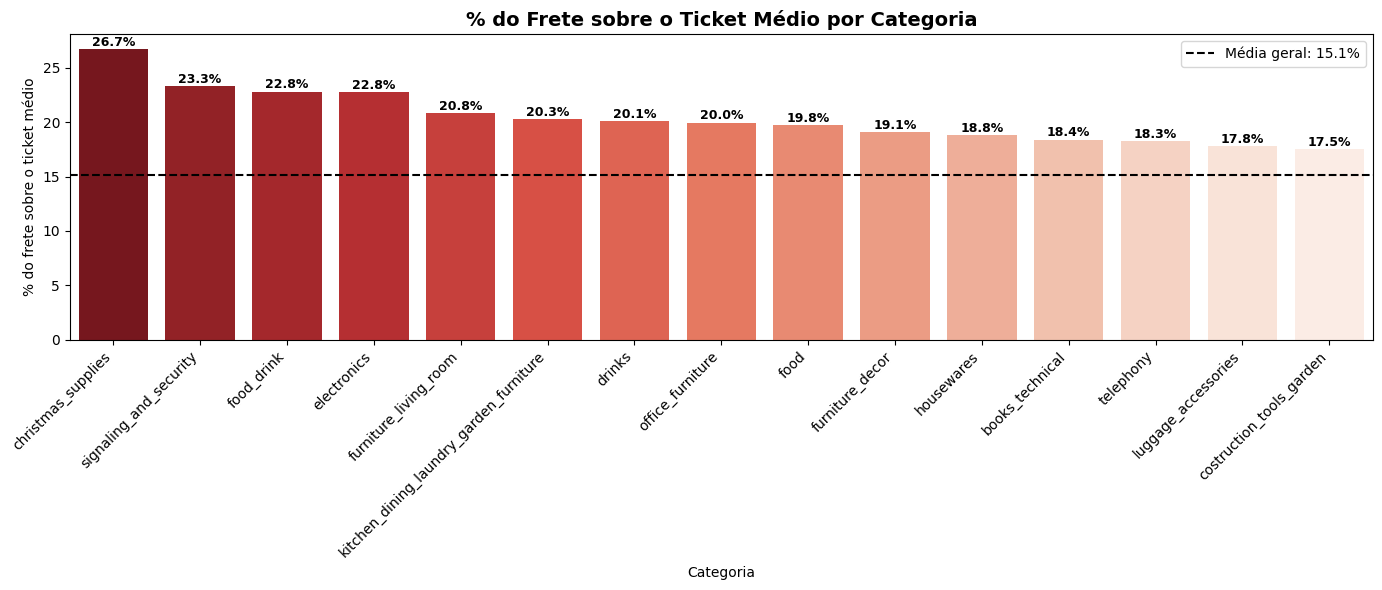

In [4]:
# ============================================================
# GRÁFICO — % DO FRETE SOBRE O TICKET MÉDIO POR CATEGORIA
# ============================================================
# Objetivo:
# Identificar quais categorias têm maior peso do frete
# em relação ao valor total médio do pedido.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa por categoria
categoria_frete = (
    df_base
    .groupby('product_category_name_english')
    .agg(
        ticket_medio=('ticket_total', 'mean'),
        frete_medio=('total_freight', 'mean'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Filtra categorias com volume mínimo para evitar distorções
categoria_frete = categoria_frete[categoria_frete['total_pedidos'] >= 100].copy()

# Calcula o % do frete sobre o ticket médio
categoria_frete['pct_frete_sobre_ticket'] = (
    categoria_frete['frete_medio'] / categoria_frete['ticket_medio'] * 100
)

# Ordena do maior para o menor
categoria_frete = categoria_frete.sort_values('pct_frete_sobre_ticket', ascending=False)

# Seleciona top categorias para melhor legibilidade
top_categorias = categoria_frete.head(15).copy()

# Cria gráfico
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=top_categorias,
    x='product_category_name_english',
    y='pct_frete_sobre_ticket',
    palette='Reds_r'
)

# Linha da média geral
media_pct = categoria_frete['pct_frete_sobre_ticket'].mean()
plt.axhline(
    media_pct,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Média geral: {media_pct:.1f}%'
)

# Rótulos nas barras
for i, v in enumerate(top_categorias['pct_frete_sobre_ticket']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('% do Frete sobre o Ticket Médio por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('% do frete sobre o ticket médio')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99355/4103946770.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


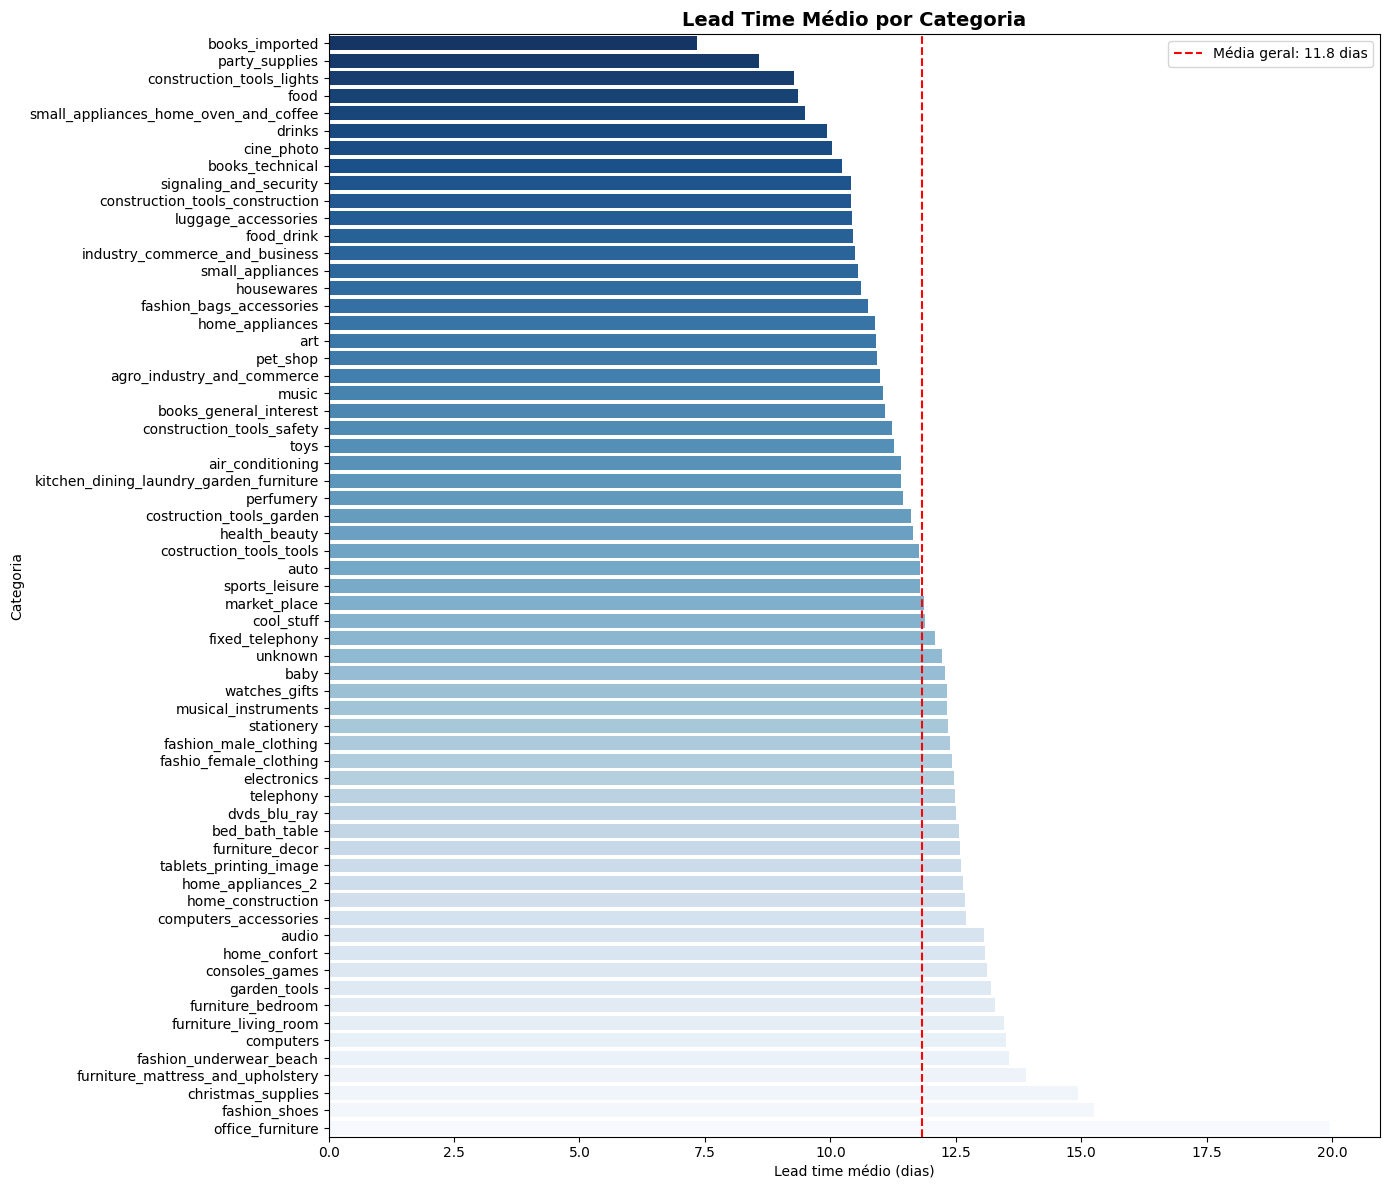

In [5]:
# ============================================================
# GRÁFICO — LEAD TIME MÉDIO POR CATEGORIA
# ============================================================
# Objetivo:
# Mostrar o tempo médio de entrega por categoria,
# considerando todas as categorias com volume mínimo relevante.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa por categoria
categoria_leadtime = (
    df_base
    .groupby('product_category_name_english')
    .agg(
        lead_time_medio=('tempo_entrega_dias', 'mean'),
        mediana_lead_time=('tempo_entrega_dias', 'median'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Filtra categorias com volume mínimo para evitar distorção
categoria_leadtime = categoria_leadtime[categoria_leadtime['total_pedidos'] >= 30].copy()

# Ordena da maior para a menor
categoria_leadtime = categoria_leadtime.sort_values('lead_time_medio', ascending=True)

# Gráfico horizontal
plt.figure(figsize=(14, 12))
ax = sns.barplot(
    data=categoria_leadtime,
    y='product_category_name_english',
    x='lead_time_medio',
    palette='Blues_r'
)

# Linha da média geral
media_geral = categoria_leadtime['lead_time_medio'].mean()
plt.axvline(
    media_geral,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Média geral: {media_geral:.1f} dias'
)

plt.title('Lead Time Médio por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Lead time médio (dias)')
plt.ylabel('Categoria')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99355/3890730822.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


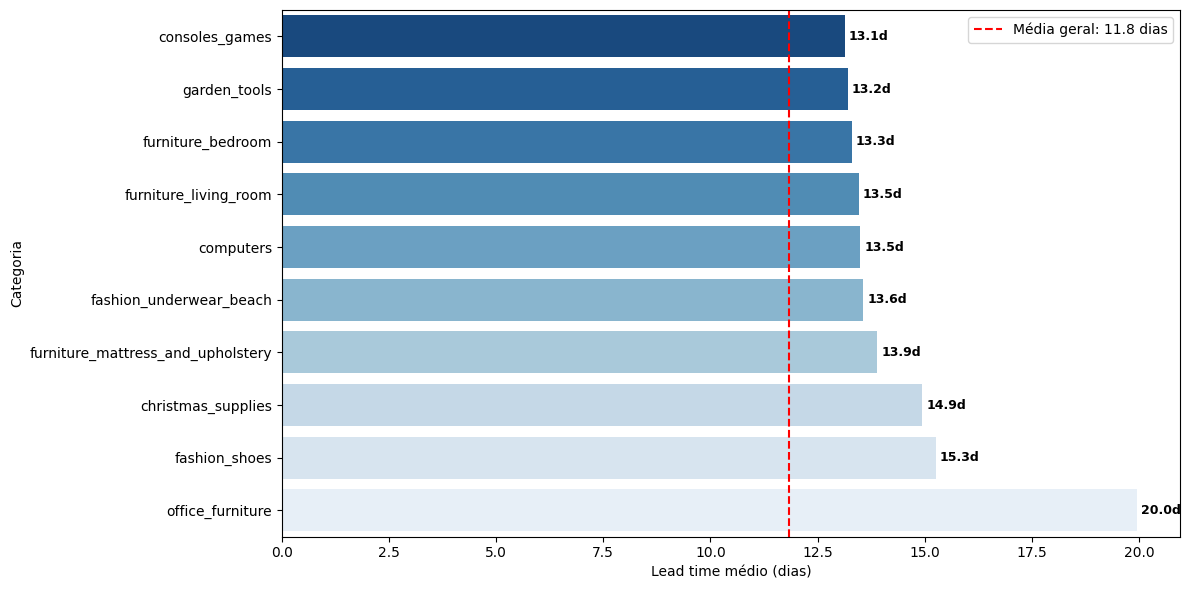

In [6]:
# ============================================================
# GRÁFICO — TOP CATEGORIAS COM MAIOR LEAD TIME MÉDIO
# ============================================================
# Objetivo:
# Identificar as categorias com maior tempo médio de entrega.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa por categoria
categoria_leadtime = (
    df_base
    .groupby('product_category_name_english')
    .agg(
        lead_time_medio=('tempo_entrega_dias', 'mean'),
        mediana_lead_time=('tempo_entrega_dias', 'median'),
        total_pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Filtra categorias com volume mínimo para evitar distorções
categoria_leadtime = categoria_leadtime[categoria_leadtime['total_pedidos'] >= 30].copy()

# Ordena pelas maiores médias
categoria_leadtime = categoria_leadtime.sort_values('lead_time_medio', ascending=False)

# Seleciona top categorias
top_categorias = categoria_leadtime.head(10).copy()

# Ordena para o gráfico horizontal ficar bonito
top_categorias = top_categorias.sort_values('lead_time_medio', ascending=True)

# Gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_categorias,
    y='product_category_name_english',
    x='lead_time_medio',
    palette='Blues_r'
)

# Linha da média das categorias filtradas
media_geral = categoria_leadtime['lead_time_medio'].mean()
plt.axvline(
    media_geral,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Média geral: {media_geral:.1f} dias'
)

# Rótulos nas barras
for i, v in enumerate(top_categorias['lead_time_medio']):
    ax.text(
        v + 0.1,
        i,
        f'{v:.1f}d',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

#plt.title('Top 10 Categorias com Maior Lead Time Médio', fontsize=14, fontweight='bold')
plt.xlabel('Lead time médio (dias)')
plt.ylabel('Categoria')
plt.legend()
plt.tight_layout()
plt.show()
